# Data Analysis and Visualization Lab 4

**Roll Number:** 24I-2513  
**Dataset:** Food Delivery Orders  
**Analysis:** Univariate, bivariate, multivariate, correlation, aggregation, time series, faceting, annotation, and overplotting


In [1]:
# Setup and data validation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', None)

df = pd.read_csv('food_delivery_orders.csv')
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Remove exact duplicates and confirm the required fields are usable.
rows_before = len(df)
df = df.drop_duplicates().copy()
required = [
    'order_date', 'city', 'restaurant_category', 'cuisine', 'order_value',
    'discount_percent', 'delivery_time_min', 'rating', 'profit_per_order'
]
df = df.dropna(subset=required)
df.to_csv('cleaned_food_delivery_orders.csv', index=False)

print('Shape:', df.shape)
print('Rows removed:', rows_before - len(df))
print('Date range:', df['order_date'].min().date(), 'to', df['order_date'].max().date())
print('Remaining missing values:', int(df[required].isna().sum().sum()))
df.head()


Shape: (4200, 9)
Rows removed: 0
Date range: 2023-01-01 to 2024-06-30
Remaining missing values: 0


,order_date,city,restaurant_category,cuisine,order_value,discount_percent,delivery_time_min,rating,profit_per_order
0,2023-01-01,Karachi,Fine Dining,Continental,2768.0,25.0,36.2,4.5,95.0
1,2023-01-01,Karachi,Fine Dining,Steakhouse,4979.0,44.8,23.3,4.8,-437.0
2,2023-01-01,Karachi,Cloud Kitchen,Indian,4008.0,11.9,39.6,4.2,618.0
3,2023-01-01,Islamabad,Fine Dining,Steakhouse,3260.0,8.3,35.8,4.5,423.0
4,2023-01-01,Karachi,Fast Food,Pizza,435.0,13.5,29.4,4.8,53.0


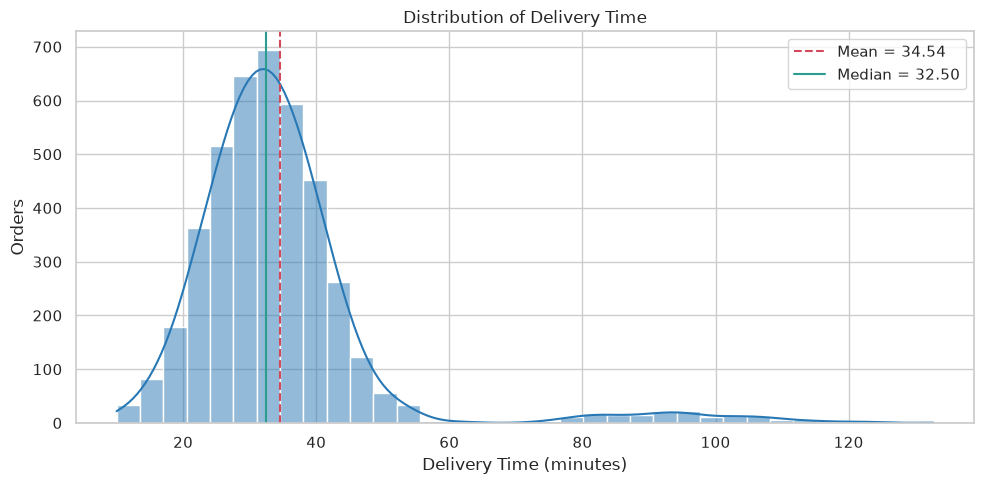

Skewness: 2.877
Mean: 34.54 minutes | Median: 32.50 minutes
Recommendation: Advertise the median of 32.5 minutes. The distribution is strongly right-skewed,
so a small number of very late deliveries pull the mean upward and make it less representative.


In [2]:
# Task 1 - Univariate Analysis of Delivery Time
delivery_mean = df['delivery_time_min'].mean()
delivery_median = df['delivery_time_min'].median()
delivery_skew = df['delivery_time_min'].skew()

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='delivery_time_min', bins=35, kde=True, color='#2878B5')
plt.axvline(delivery_mean, color='#D1495B', linestyle='--', label=f'Mean = {delivery_mean:.2f}')
plt.axvline(delivery_median, color='#2A9D8F', linestyle='-', label=f'Median = {delivery_median:.2f}')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Orders')
plt.title('Distribution of Delivery Time')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Skewness: {delivery_skew:.3f}')
print(f'Mean: {delivery_mean:.2f} minutes | Median: {delivery_median:.2f} minutes')
print('Recommendation: Advertise the median of 32.5 minutes. The distribution is strongly right-skewed,')
print('so a small number of very late deliveries pull the mean upward and make it less representative.')


             mean  median    std  count
city                                   
Multan      4.521     4.6  0.401    386
Faisalabad  4.490     4.5  0.384    492
Islamabad   4.512     4.5  0.374    835
Karachi     4.508     4.5  0.380   1163
Lahore      4.511     4.5  0.397   1324


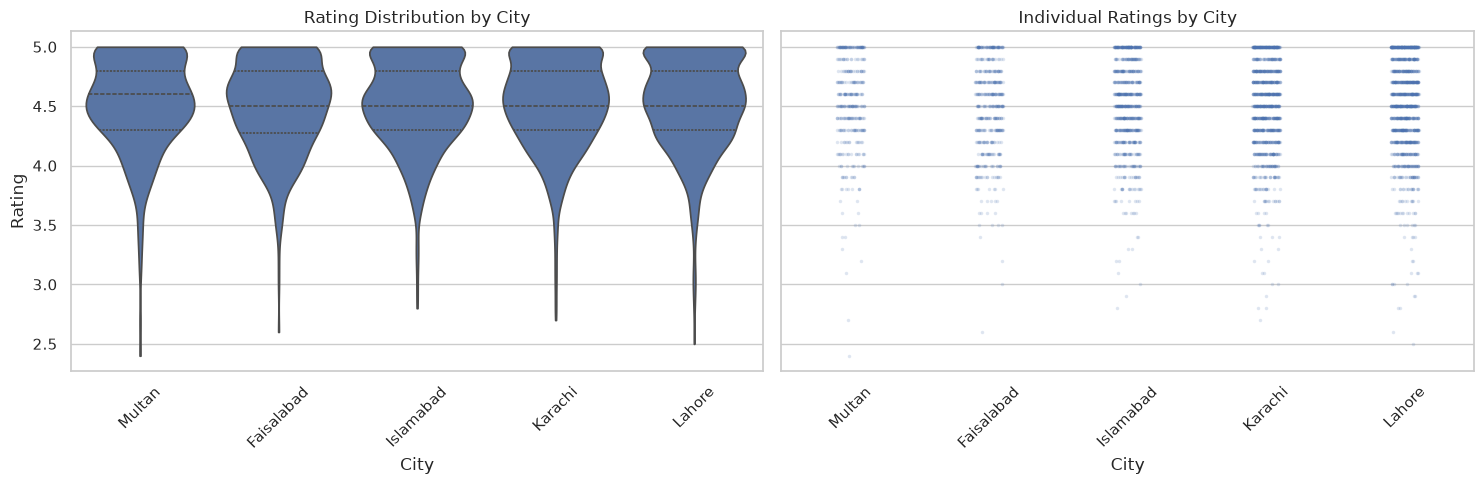

Interpretation: Ratings are tightly concentrated near 4.5 in every city. Multan has the highest
median (4.6), but the substantial overlap shows that city differences are small in practical terms.


In [3]:
# Task 2 - Categorical x Numerical Analysis: Rating by City
city_rating = df.groupby('city')['rating'].agg(['mean', 'median', 'std', 'count']).round(3)
print(city_rating.sort_values('median', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
order = city_rating.sort_values('median', ascending=False).index
sns.violinplot(data=df, x='city', y='rating', order=order, inner='quartile', cut=0, ax=axes[0])
axes[0].set_title('Rating Distribution by City')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Rating')
axes[0].tick_params(axis='x', rotation=45)

sns.stripplot(data=df, x='city', y='rating', order=order, jitter=True, alpha=0.18, size=2.5, ax=axes[1])
axes[1].set_title('Individual Ratings by City')
axes[1].set_xlabel('City')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('Interpretation: Ratings are tightly concentrated near 4.5 in every city. Multan has the highest')
print('median (4.6), but the substantial overlap shows that city differences are small in practical terms.')


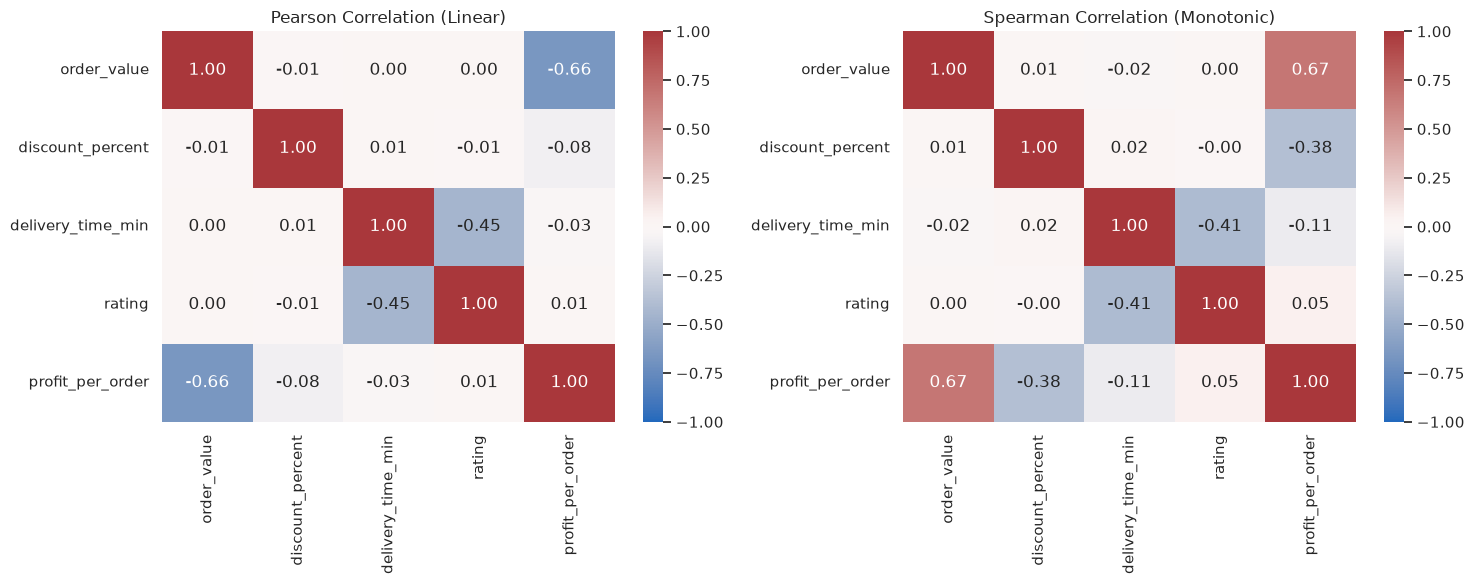

Delivery time vs rating: Pearson = -0.445, Spearman = -0.413
Order value vs profit: Pearson = -0.657, Spearman = 0.673
Interpretation: Delivery time and rating have a moderate negative relationship. The sign reversal
for order value and profit suggests outliers or a non-linear rule; correlation alone does not prove causation.


In [4]:
# Task 3 - Pearson and Spearman Correlation
numeric_columns = ['order_value', 'discount_percent', 'delivery_time_min', 'rating', 'profit_per_order']
pearson = df[numeric_columns].corr(method='pearson')
spearman = df[numeric_columns].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(pearson, annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson Correlation (Linear)')
sns.heatmap(spearman, annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman Correlation (Monotonic)')
plt.tight_layout()
plt.show()

print(f"Delivery time vs rating: Pearson = {pearson.loc['delivery_time_min', 'rating']:.3f}, "
      f"Spearman = {spearman.loc['delivery_time_min', 'rating']:.3f}")
print(f"Order value vs profit: Pearson = {pearson.loc['order_value', 'profit_per_order']:.3f}, "
      f"Spearman = {spearman.loc['order_value', 'profit_per_order']:.3f}")
print('Interpretation: Delivery time and rating have a moderate negative relationship. The sign reversal')
print('for order value and profit suggests outliers or a non-linear rule; correlation alone does not prove causation.')


Top city-category combinations by total profit:


sum    mean  median     std  count
city       restaurant_category                                         
Lahore     Cloud Kitchen        44587.01  137.61   131.5  316.04    324
Karachi    Fine Dining          42695.00  302.80   272.0  252.05    141
           Cloud Kitchen        36374.30  136.75   122.0  370.40    266
Lahore     Fine Dining          19497.83  159.82   245.0  791.06    122
Islamabad  Fine Dining          13780.61  153.12   236.5  743.04     90
Faisalabad Fine Dining          13510.00  293.70   234.5  250.56     46
Lahore     Dessert              13103.00   65.52    47.5   85.05    200
           Cafe                 12981.73   52.35    61.0  335.35    248
Islamabad  Cloud Kitchen        11687.34   57.01   141.0  691.88    205
Karachi    Dessert              11587.00   75.24    63.0   73.98    154

restaurant_category,Cafe,Cloud Kitchen,Dessert,Fast Food,Fine Dining,All
city,,,,,,
Faisalabad,5922.0,8157.0,-5273.0,3215.0,13510.0,25531.0
Islamabad,-2106.0,11687.0,-3430.0,9703.0,13781.0,29636.0
Karachi,-9842.0,36374.0,11587.0,5366.0,42695.0,86180.0
Lahore,12982.0,44587.0,13103.0,4566.0,19498.0,94736.0
Multan,5232.0,-7782.0,2905.0,-4894.0,9411.0,4872.0
All,12188.0,93024.0,18892.0,17957.0,98894.0,240954.0


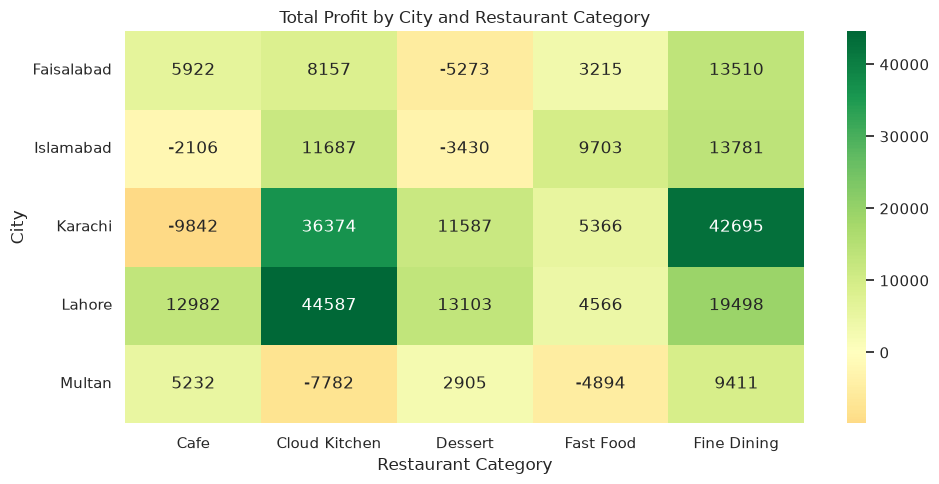

Interpretation: Lahore Cloud Kitchens lead total profit, while Karachi Fine Dining has the
largest average among the leading combinations. The pivot totals also expose loss-making segments.


In [5]:
# Task 4 - Multi-Level Aggregation and Pivot Table
profit_summary = (
    df.groupby(['city', 'restaurant_category'])['profit_per_order']
      .agg(['sum', 'mean', 'median', 'std', 'count'])
      .round(2)
      .sort_values('sum', ascending=False)
)
print('Top city-category combinations by total profit:')
display(profit_summary.head(10))

profit_pivot = pd.pivot_table(
    df,
    index='city',
    columns='restaurant_category',
    values='profit_per_order',
    aggfunc='sum',
    margins=True
).round(0)
display(profit_pivot)

plt.figure(figsize=(10, 5))
sns.heatmap(profit_pivot.drop(index='All', columns='All'), annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Total Profit by City and Restaurant Category')
plt.xlabel('Restaurant Category')
plt.ylabel('City')
plt.tight_layout()
plt.show()

print('Interpretation: Lahore Cloud Kitchens lead total profit, while Karachi Fine Dining has the')
print('largest average among the leading combinations. The pivot totals also expose loss-making segments.')


,total_order_value,total_profit,order_count,profit_3_month_average
order_date,,,,
2023-01-31,304992.80,7502.56,221,NaN
2023-02-28,228854.24,18366.39,214,NaN
2023-03-31,262300.00,29780.00,263,18549.65
2023-04-30,265703.24,11296.63,235,19814.34
2023-05-31,244021.06,6903.84,227,15993.49
2023-06-30,279027.04,13727.00,245,10642.49
2023-07-31,214324.70,19326.34,213,13319.06
2023-08-31,271187.04,17855.53,251,16969.62
2023-09-30,270409.49,12089.22,249,16423.70


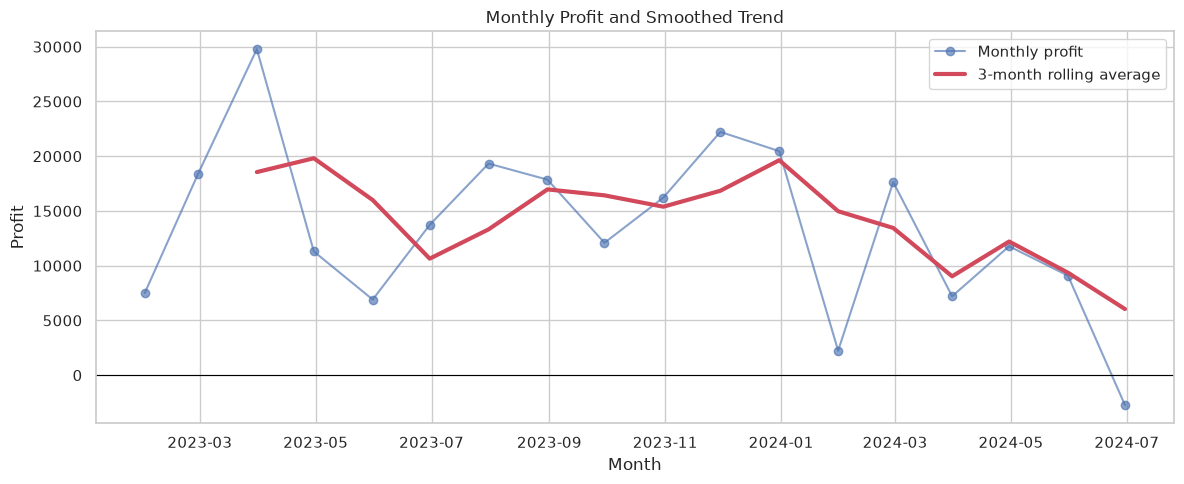

Peak monthly profit: March 2023 (29,780)
Lowest monthly profit: June 2024 (-2,741)
Interpretation: Resampling removes transaction-level noise; the rolling average shows a weakening
profit trend in early 2024, ending with a loss in June 2024.


In [6]:
# Task 5 - Monthly Resampling and Rolling Trend
monthly = (
    df.set_index('order_date')
      .resample('ME')
      .agg(total_order_value=('order_value', 'sum'),
           total_profit=('profit_per_order', 'sum'),
           order_count=('profit_per_order', 'size'))
)
monthly['profit_3_month_average'] = monthly['total_profit'].rolling(window=3).mean()
display(monthly.round(2))

plt.figure(figsize=(12, 5))
plt.plot(monthly.index, monthly['total_profit'], marker='o', alpha=0.65, label='Monthly profit')
plt.plot(monthly.index, monthly['profit_3_month_average'], linewidth=3, color='#D1495B', label='3-month rolling average')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Month')
plt.ylabel('Profit')
plt.title('Monthly Profit and Smoothed Trend')
plt.legend()
plt.tight_layout()
plt.show()

peak = monthly['total_profit'].idxmax()
low = monthly['total_profit'].idxmin()
print(f"Peak monthly profit: {peak:%B %Y} ({monthly.loc[peak, 'total_profit']:,.0f})")
print(f"Lowest monthly profit: {low:%B %Y} ({monthly.loc[low, 'total_profit']:,.0f})")
print('Interpretation: Resampling removes transaction-level noise; the rolling average shows a weakening')
print('profit trend in early 2024, ending with a loss in June 2024.')


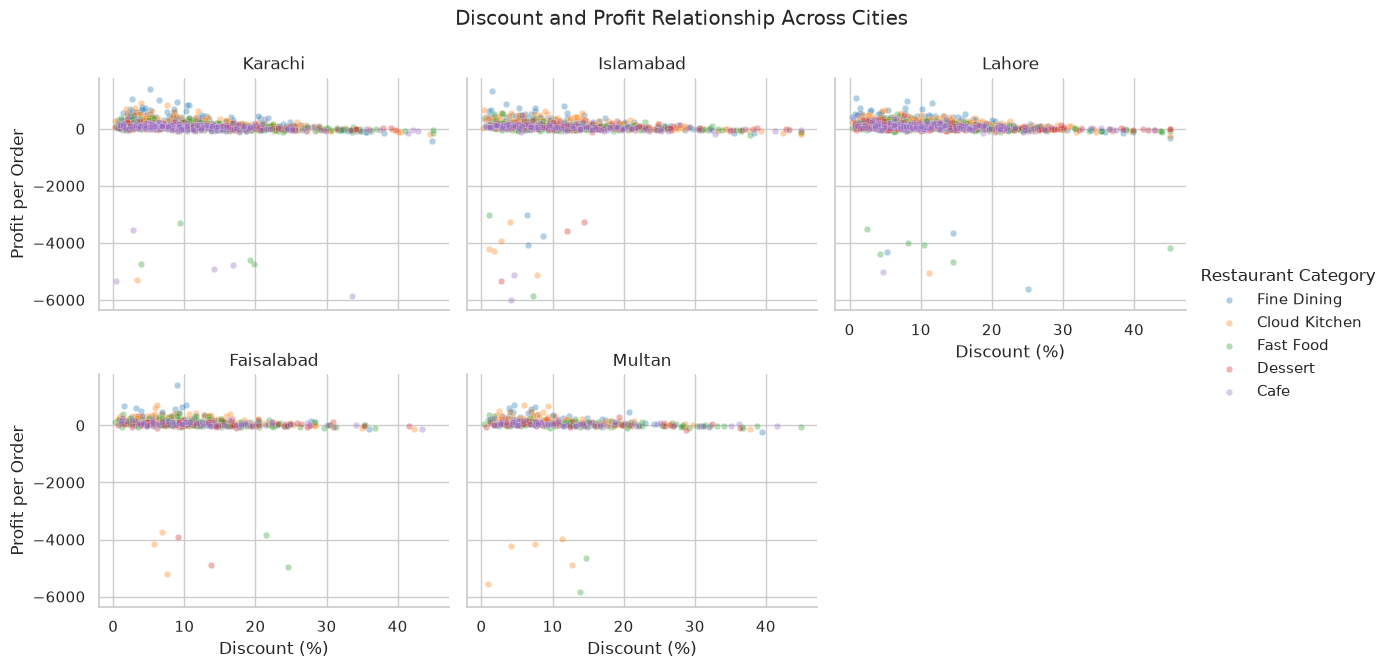

Karachi      -0.132
Lahore       -0.128
Faisalabad   -0.100
Multan       -0.040
Islamabad     0.001
Name: discount_profit_correlation, dtype: float64
Interpretation: The facets reveal weak negative linear relationships in most cities; the effect
is most visible in Karachi and Lahore, while Islamabad is approximately flat.


In [7]:
# Task 6 - Faceted Multivariate Comparison
g = sns.FacetGrid(
    df, col='city', col_wrap=3, hue='restaurant_category',
    height=3.4, aspect=1.2, palette='tab10'
)
g.map_dataframe(
    sns.scatterplot, x='discount_percent', y='profit_per_order',
    alpha=0.35, s=22
)
g.add_legend(title='Restaurant Category')
g.set_axis_labels('Discount (%)', 'Profit per Order')
g.set_titles('{col_name}')
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle('Discount and Profit Relationship Across Cities')
plt.show()

city_discount_profit = pd.Series({
    city: group['discount_percent'].corr(group['profit_per_order'])
    for city, group in df.groupby('city')
}, name='discount_profit_correlation').sort_values()
print(city_discount_profit.round(3))
print('Interpretation: The facets reveal weak negative linear relationships in most cities; the effect')
print('is most visible in Karachi and Lahore, while Islamabad is approximately flat.')


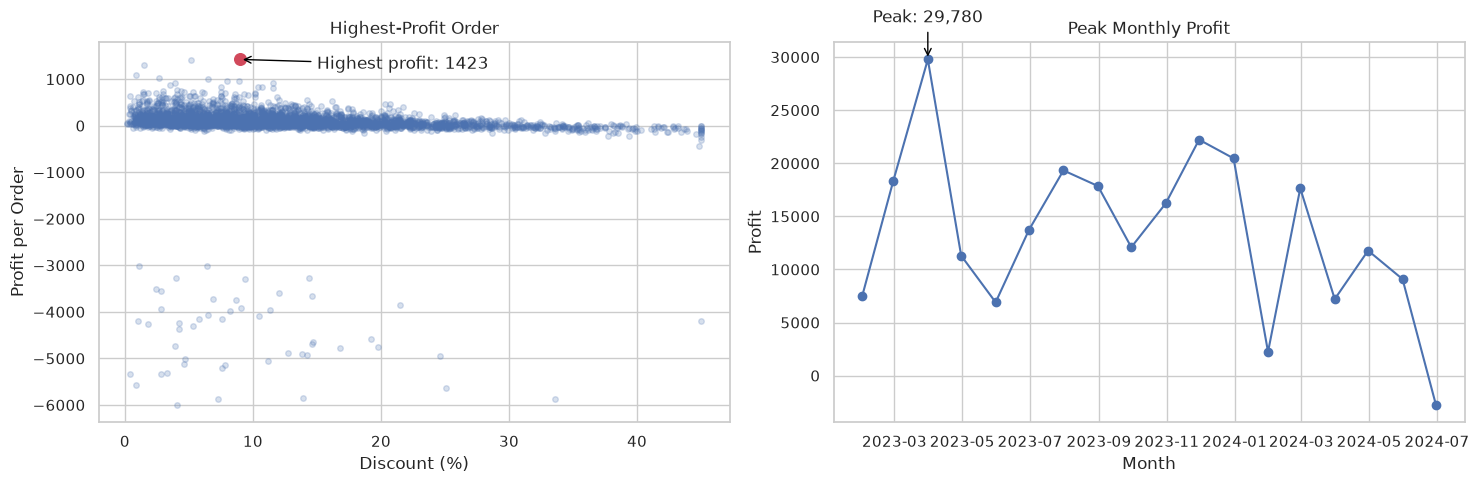

Highest-profit order: Faisalabad, Fine Dining, 9.0% discount, profit 1423.


In [8]:
# Task 7 - Value-Adding Annotations
best = df.loc[df['profit_per_order'].idxmax()]
monthly_best = monthly['total_profit'].idxmax()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].scatter(df['discount_percent'], df['profit_per_order'], alpha=0.22, s=16)
axes[0].scatter(best['discount_percent'], best['profit_per_order'], color='#D1495B', s=70, zorder=3)
axes[0].annotate(
    f"Highest profit: {best['profit_per_order']:.0f}",
    xy=(best['discount_percent'], best['profit_per_order']),
    xytext=(best['discount_percent'] + 6, best['profit_per_order'] - 200),
    arrowprops=dict(arrowstyle='->', color='black')
)
axes[0].set(xlabel='Discount (%)', ylabel='Profit per Order', title='Highest-Profit Order')

axes[1].plot(monthly.index, monthly['total_profit'], marker='o')
axes[1].annotate(
    f"Peak: {monthly.loc[monthly_best, 'total_profit']:,.0f}",
    xy=(monthly_best, monthly.loc[monthly_best, 'total_profit']),
    xytext=(monthly_best, monthly['total_profit'].max() + 3500),
    ha='center', arrowprops=dict(arrowstyle='->', color='black')
)
axes[1].set(xlabel='Month', ylabel='Profit', title='Peak Monthly Profit')
plt.tight_layout()
plt.show()

print(f"Highest-profit order: {best['city']}, {best['restaurant_category']}, "
      f"{best['discount_percent']:.1f}% discount, profit {best['profit_per_order']:.0f}.")


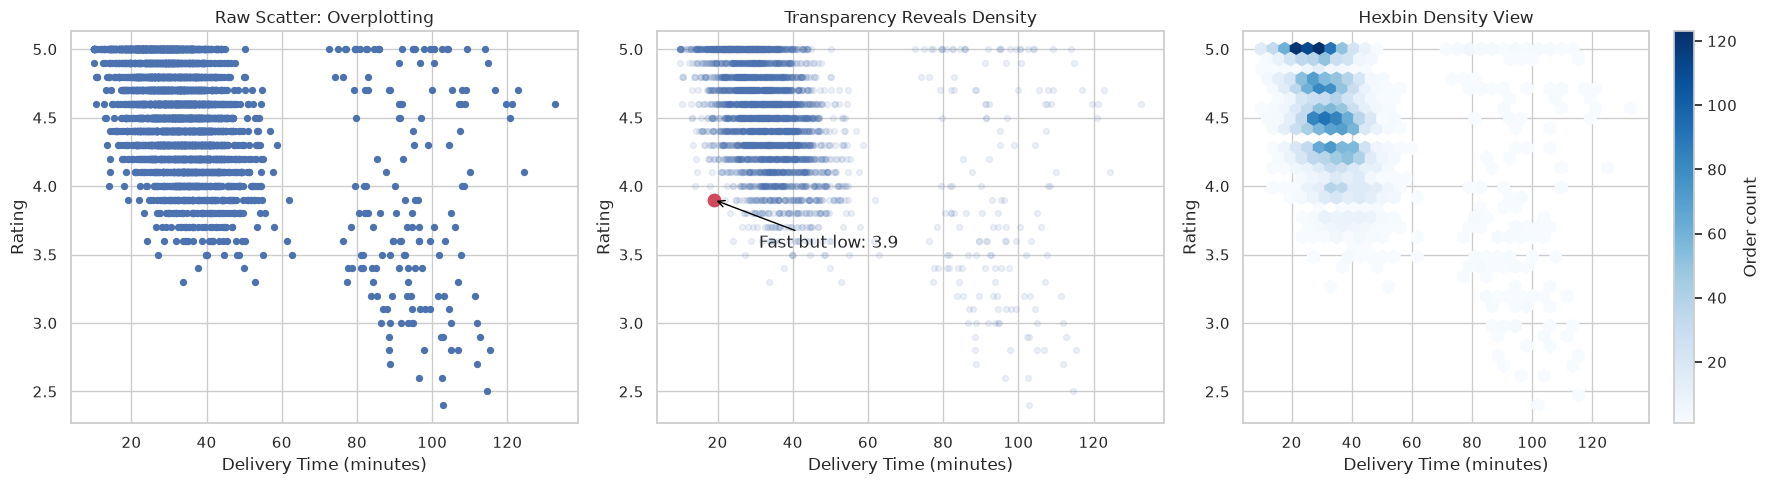

Fast-delivery threshold (10th percentile): 22.0 minutes
Worst rating among unusually fast deliveries: 3.9 at 19.0 minutes
Interpretation: The raw scatter stacks thousands of repeated ratings into dark bands. Transparency
and hexbinning reveal density, while the annotation shows that fast delivery alone does not ensure a high rating.


In [9]:
# Task 8 - Diagnose and Correct Overplotting
fast_threshold = df['delivery_time_min'].quantile(0.10)
fast_worst = (
    df[df['delivery_time_min'] <= fast_threshold]
    .sort_values(['rating', 'delivery_time_min'])
    .iloc[0]
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(df['delivery_time_min'], df['rating'], s=18)
axes[0].set_title('Raw Scatter: Overplotting')

axes[1].scatter(df['delivery_time_min'], df['rating'], alpha=0.10, s=18)
axes[1].set_title('Transparency Reveals Density')

hb = axes[2].hexbin(df['delivery_time_min'], df['rating'], gridsize=32, cmap='Blues', mincnt=1)
fig.colorbar(hb, ax=axes[2], label='Order count')
axes[2].set_title('Hexbin Density View')

for ax in axes:
    ax.set_xlabel('Delivery Time (minutes)')
    ax.set_ylabel('Rating')

axes[1].scatter(fast_worst['delivery_time_min'], fast_worst['rating'], color='#D1495B', s=80, zorder=3)
axes[1].annotate(
    f"Fast but low: {fast_worst['rating']:.1f}",
    xy=(fast_worst['delivery_time_min'], fast_worst['rating']),
    xytext=(fast_worst['delivery_time_min'] + 12, fast_worst['rating'] - 0.35),
    arrowprops=dict(arrowstyle='->', color='black')
)
plt.tight_layout()
plt.show()

print(f"Fast-delivery threshold (10th percentile): {fast_threshold:.1f} minutes")
print(f"Worst rating among unusually fast deliveries: {fast_worst['rating']:.1f} at "
      f"{fast_worst['delivery_time_min']:.1f} minutes")
print('Interpretation: The raw scatter stacks thousands of repeated ratings into dark bands. Transparency')
print('and hexbinning reveal density, while the annotation shows that fast delivery alone does not ensure a high rating.')
